# Phase 1 new-experiment batch — Experiment C (windowed flow vs. null)

Companion notebook to `reports/phase1_newexperiments_preregistration.md`.

**Question**: is the donor→receiver matter-flow structure between consecutive
time windows more persistent than expected under identity-shuffled pairing?

- Data: 9 metabolic-trace runs (multipliers 0.5/2/16 × seeds 0–2, 256 tapes,
  20,000 epochs) with `--flow-window 2000` → 10 window matrices per run.
- Statistic: Spearman correlation of edge weights between consecutive windows.
- Null: donor/receiver labels permuted within the later window
  (2,000-run ensemble uses 200 resamples per window pair; seeded RNG).


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from experiments.analyze_phase1_newexperiments import (
    TRACE_WINDOWS,
    ROOT,
    paired_permutation,
    spearman,
)

pd.set_option("display.width", 160)

## 1. Load windowed flows and compute observed vs. null correlations

In [2]:
def window_matrix(edges: pd.DataFrame, window: int, size: int) -> np.ndarray:
    sub = edges[edges["window"] == window]
    matrix = np.zeros((size, size))
    matrix[sub["donor_tape"].to_numpy(), sub["receiver_tape"].to_numpy()] = sub["token_transfers"]
    return matrix


rows = []
curves = {}
for run_dir in sorted(TRACE_WINDOWS.glob("trace_m*_n256_s*")):
    manifest = json.loads((run_dir / "manifest.json").read_text())
    if manifest.get("exit_status") != "success":
        continue
    cfg = manifest["config"]
    edges = pd.read_csv(run_dir / "flow_edges_windows.csv")
    n_windows = int(edges["window"].max()) + 1
    size = int(cfg["population_size"])
    rng = np.random.default_rng(10_000 + int(cfg["seed"]))
    matrices = [window_matrix(edges, w, size) for w in range(n_windows)]
    observed, nulls = [], []
    for w in range(n_windows - 1):
        obs = spearman(matrices[w].ravel(), matrices[w + 1].ravel())[0]
        observed.append(obs)
        nulls.append(float(np.mean([
            spearman(matrices[w].ravel(), matrices[w + 1][rng.permutation(size)][:, rng.permutation(size)].ravel())[0]
            for _ in range(200)
        ])))
    curves[run_dir.name] = {"observed": observed, "null": nulls}
    rows.append({
        "pool_multiplier": cfg["pool_multiplier"],
        "seed": cfg["seed"],
        "n_windows": n_windows,
        "observed_mean_corr": float(np.nanmean(observed)),
        "null_mean_corr": float(np.nanmean(nulls)),
        "gap": float(np.nanmean(observed) - np.nanmean(nulls)),
    })
c_runs = pd.DataFrame(rows).sort_values(["pool_multiplier", "seed"])
print(f"Experiment C: {len(c_runs)} completed runs")
c_runs

Experiment C: 9 completed runs


,pool_multiplier,seed,n_windows,observed_mean_corr,null_mean_corr,gap
0,0.5,0,10,0.190824,-0.000177,0.191000
1,0.5,1,10,0.203730,0.000375,0.203355
2,0.5,2,10,0.192272,0.000081,0.192191
6,2.0,0,10,0.186255,0.000556,0.185700
7,2.0,1,10,0.180236,0.000559,0.179677
8,2.0,2,10,0.191982,0.000599,0.191382
3,16.0,0,10,0.186513,0.000040,0.186473
4,16.0,1,10,0.200016,0.001047,0.198969
5,16.0,2,10,0.203939,0.000718,0.203221


## 2. C1 — flow persistence above null (paired permutation test)

In [3]:
if len(c_runs):
    observed_gaps = c_runs["observed_mean_corr"].to_numpy()
    null_gaps = c_runs["null_mean_corr"].to_numpy()
    mean_gap, p_c1, effect = paired_permutation(observed_gaps, null_gaps)
    print(f"C1: mean observed corr = {observed_gaps.mean():.4f}, mean null corr = {null_gaps.mean():.4f}")
    print(f"     mean gap = {mean_gap:+.4f}, one-sided paired permutation p = {p_c1:.4f}")
    print(f"     decision: {'REJECT well-mixed null (persistent flow structure)' if p_c1 < 0.05 else 'DO NOT REJECT null (well-mixed recycling; H2 closes negative)'}")

C1: mean observed corr = 0.1929, mean null corr = 0.0004
     mean gap = +0.1924, one-sided paired permutation p = 0.0025
     decision: REJECT well-mixed null (persistent flow structure)


## 3. C2 — does scarcity sharpen flow structure? (multiplier vs. gap)

In [4]:
if len(c_runs):
    rho_c2, p_c2 = spearman(c_runs["pool_multiplier"].to_numpy(), c_runs["gap"].to_numpy())
    print(f"C2: Spearman rho = {rho_c2:.3f}, p = {p_c2:.4f} (n = {len(c_runs)})")
    print(c_runs.groupby("pool_multiplier")[["observed_mean_corr", "null_mean_corr", "gap"]].mean())

C2: Spearman rho = -0.053, p = 1.0000 (n = 9)
                 observed_mean_corr  null_mean_corr       gap
pool_multiplier                                              
0.5                        0.195608        0.000093  0.195516
2.0                        0.186158        0.000571  0.185586
16.0                       0.196823        0.000602  0.196221


## 3b. Robustness — persistence excluding self-flow (diagonal)

In [5]:
if len(c_runs):
    def window_matrix_offdiag(edges: pd.DataFrame, window: int, size: int) -> np.ndarray:
        sub = edges[edges["window"] == window]
        matrix = np.zeros((size, size))
        matrix[sub["donor_tape"].to_numpy(), sub["receiver_tape"].to_numpy()] = sub["token_transfers"]
        np.fill_diagonal(matrix, 0.0)
        return matrix

    offdiag_gaps = []
    for run_dir in sorted(TRACE_WINDOWS.glob("trace_m*_n256_s*")):
        manifest = json.loads((run_dir / "manifest.json").read_text())
        if manifest.get("exit_status") != "success":
            continue
        cfg = manifest["config"]
        edges = pd.read_csv(run_dir / "flow_edges_windows.csv")
        n_windows = int(edges["window"].max()) + 1
        size = int(cfg["population_size"])
        rng = np.random.default_rng(10_000 + int(cfg["seed"]))
        mats = [window_matrix_offdiag(edges, w, size) for w in range(n_windows)]
        obs = [spearman(mats[w].ravel(), mats[w + 1].ravel())[0] for w in range(n_windows - 1)]
        nul = [np.mean([spearman(mats[w].ravel(), mats[w + 1][rng.permutation(size)][:, rng.permutation(size)].ravel())[0] for _ in range(100)]) for w in range(n_windows - 1)]
        offdiag_gaps.append(float(np.mean(obs) - np.mean(nul)))
    print(f"off-diagonal-only observed-minus-null gap: mean = {np.mean(offdiag_gaps):+.4f}")
    print(f"per-run gaps: {[round(g, 3) for g in offdiag_gaps]}")
    print("persistent structure is not an artifact of stable self-flow.")

off-diagonal-only observed-minus-null gap: mean = +0.1893
per-run gaps: [0.187, 0.199, 0.186, 0.186, 0.199, 0.202, 0.182, 0.175, 0.186]
persistent structure is not an artifact of stable self-flow.


## 4. Window-by-window persistence curves

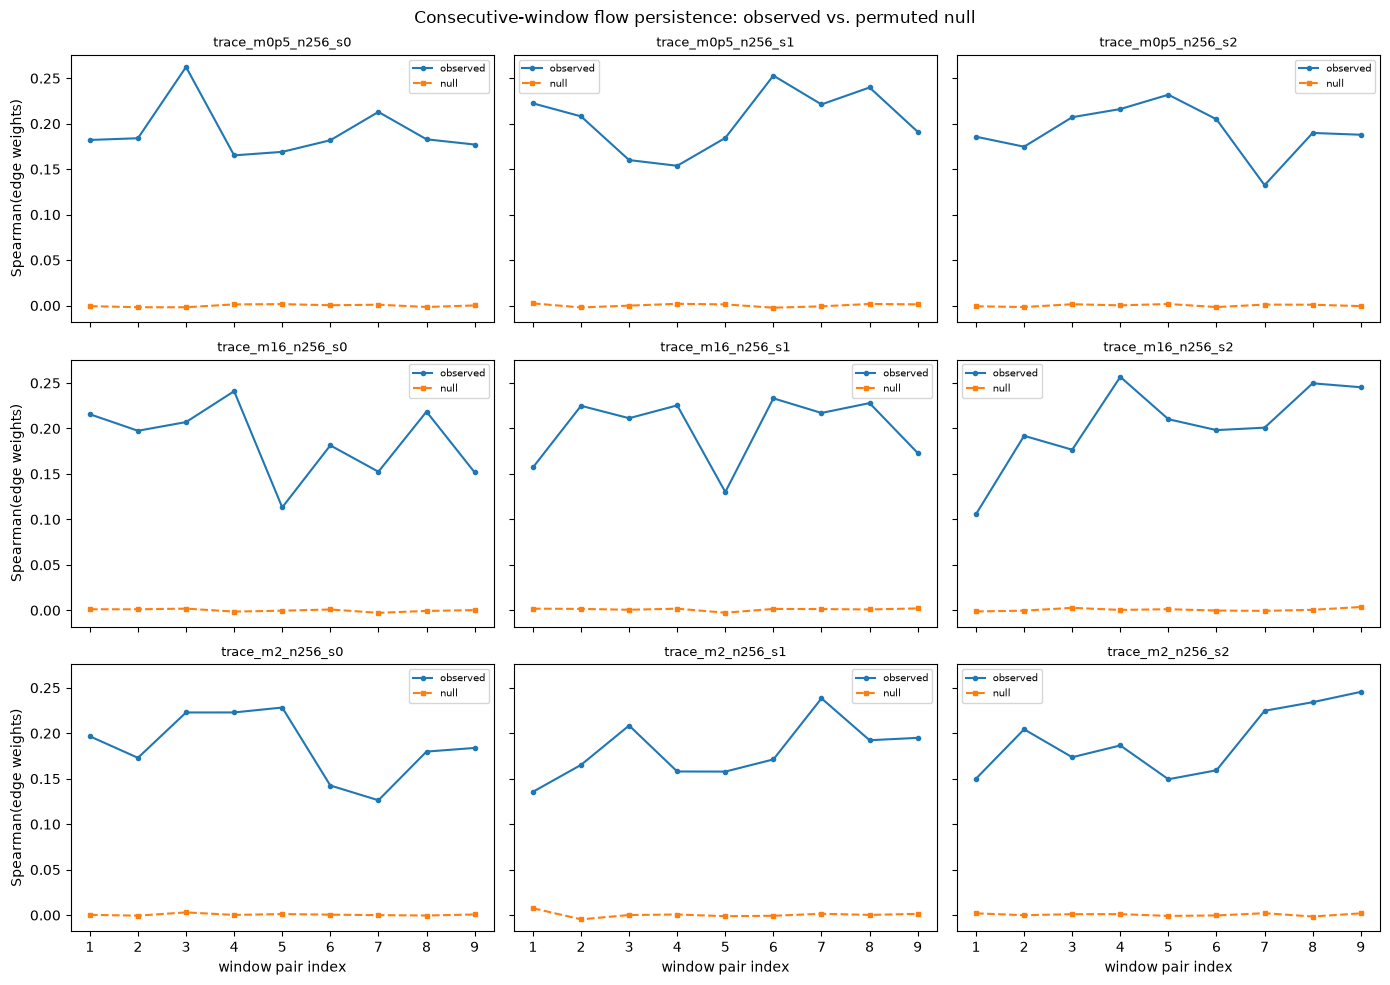

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharex=True, sharey=True)
for ax, (name, curve) in zip(axes.ravel(), sorted(curves.items())):
    ax.plot(np.arange(1, len(curve["observed"]) + 1), curve["observed"], "o-", label="observed", ms=3)
    ax.plot(np.arange(1, len(curve["null"]) + 1), curve["null"], "s--", label="null", ms=3)
    ax.set_title(name, fontsize=9)
    ax.legend(fontsize=7)
for ax in axes[-1]:
    ax.set_xlabel("window pair index")
for ax in axes[:, 0]:
    ax.set_ylabel("Spearman(edge weights)")
fig.suptitle("Consecutive-window flow persistence: observed vs. permuted null")
plt.tight_layout(); plt.show()

## 5. Interpretation

If C1's null is not rejected, the aggregate "nearly complete" donor→receiver
graphs from the earlier campaign were not hiding window-scale organizations at
256 tapes — matter circulation is well mixed at every scale measured here, and
the organization search should move to larger populations with event-level
logging. A significant positive gap would justify modularity/trophic analysis
(`analysis/organizations.py` planning docs) on the windowed graphs.